# **Klasifikasi Label Produk | Support Vector Machine (SVM)**

Klasifikasi produk pada beberapa label tertentu menggunakan algoritma Support Vector Machine.

## 1. Data Understanding & Exploratory Data Analysis

### 1.1 Import Library

In [65]:
# Impor pustaka yang dibutuhkan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

### 1.2 Import & Understanding Dataset

In [66]:
# Impor dataset
product = pd.read_csv('product_category.csv')

In [67]:
# Tampilkan 5 baris teratas
print('\n5 baris teratas:')
product.head()


5 baris teratas:


,Weight,Price,Label
0,902,580,0
1,1235,891,0
2,1070,662,0
3,906,918,0
4,871,788,0


In [68]:
# Tampilkan ringkasan informasi
print('\nRingkasan informasi:')
product.info()


Ringkasan informasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  200 non-null    int64
 1   Price   200 non-null    int64
 2   Label   200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


In [69]:
# Tampilkan dimensi dataset
print('\nDimensi dataset:')
print('Jumlah baris:', product.shape[0])
print('Jumlah kolom:', product.shape[1])


Dimensi dataset:
Jumlah baris: 200
Jumlah kolom: 3


In [70]:
# Tamplikan nilai unik per fitur
print('\nNilai unik per fitur:')
for col in product.columns:
    print(f'Jumlah nilai unik fitur {col}:', product[col].nunique())
    print('Nilai unik:', product[col].unique())
    print('\n')


Nilai unik per fitur:
Jumlah nilai unik fitur Weight: 190
Nilai unik: [ 902 1235 1070  906  871  820 1414  921 1266 1014 1130 1258  887 1172
  899 1463  930 1461 1108 1143 1291 1213 1185  991 1076  960 1259 1113
  821 1052 1360 1274  858 1310 1481 1275 1499  989 1486 1362 1366 1043
 1304 1284 1446  966 1073 1187 1400 1115  813 1041 1145 1364 1139  891
 1166 1254 1227 1308  834 1005  880 1361  801 1189 1365  905 1276 1201
 1355  961 1001 1069 1255 1261 1051 1095 1137  852 1016  987 1179 1292
  840  956  814  864 1320  928 1447 1271  862  938 1298 2782 2882 2209
 2979 2934 2148 1817 2748 2757 2183 2163 2897 2995 2756 2636 1941 2063
 2791 2909 2910 2451 2604 2198 1612 1501 2141 1719 2354 1884 2926 2653
 2576 2229 2939 1746 2335 2962 1702 2707 1622 1900 2266 1793 1779 2383
 1697 2481 2251 1643 2108 2724 2647 1686 2849 1963 2872 2159 2263 2454
 1902 2869 1646 2671 2363 1988 2428 2050 1837 2371 2140 1972 1650 2938
 2821 1762 1845 2123 2516 2380 2396 2827 1753 1952 2560 2683 2514 1508
 2622 

### 1.3 Missing Value & Data Duplikat

#### 1.3.1 Missing Value

In [71]:
# Tampilkan total nilai kosong 
print('\nTotal nilai kosong:', product.isnull().sum().sum())


Total nilai kosong: 0


#### 1.3.2 Data Duplikat 

In [72]:
# Tampilkan data duplikat 
print('\nTotal baris duplikat:', product.duplicated().sum())


Total baris duplikat: 0


---

**Kesimpulan data understanding:** 
- Jumlah dataset yang tergolong sedikit, cocok untuk algoritma SVM. Karena SVM, fokus pada Super vector. Namun, ini bisa menyebabkan overfitting, karena memaksan ukuran margin yang besar.
- Tidak ada data duplikat, missing value, serta nilai unik pada labelnya tidak ada anomali, sehingga dataset bersih.
- Fitur Independent : 'Weight', 'Price', Fitur Dependent: 'Label'.


---

### 1.4 Exploratory Data Analysis

#### 1.4.1 Multivariate Analysis

In [73]:
# Tampilkan statistik datataset 
print('\nStatistik dataset:')
product.describe()


Statistik dataset:


,Weight,Price,Label
count,200.000000,200.000000,200.000000
mean,1706.745000,543.420000,0.500000
std,681.024531,225.206044,0.501255
min,801.000000,203.000000,0.000000
25%,1135.250000,356.250000,0.000000
50%,1500.000000,501.000000,0.500000
75%,2320.000000,730.000000,1.000000
max,2995.000000,989.000000,1.000000


- Fitur 'Weight' dan 'Price' memiliki std yang besar, sehingga penyebaran data bervariasi. 
- Selisih dari quantile 75% dengan nilai max, pada fitur 'Weight' dan 'Price' tidak ekstrim, sehingga kecil kemungkinan memiliki outlier yang ekstrim

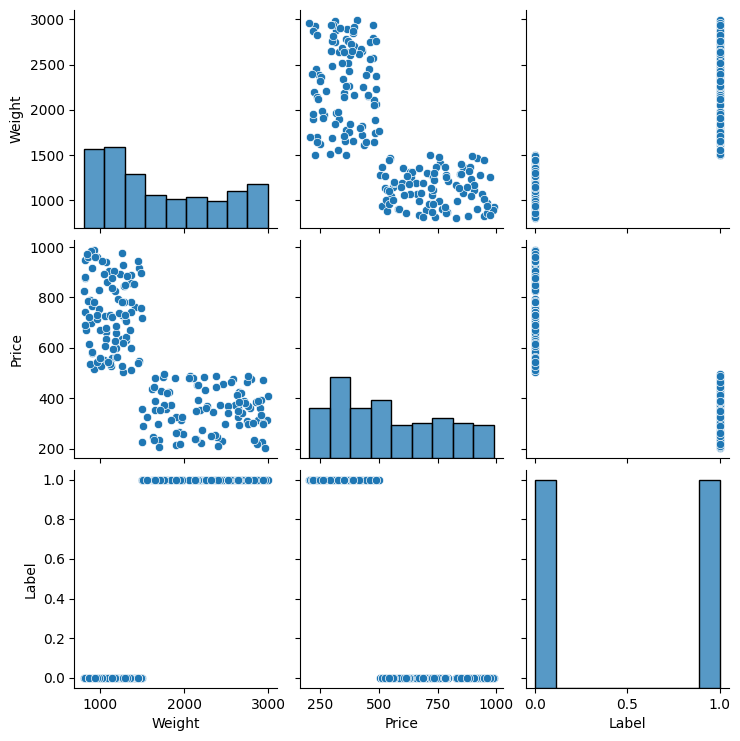

In [74]:
# Visualisasi pairplot 
sns.pairplot(product)
plt.show()

- Visualalisasi 2 fitur 'Weight' dan 'Price' memiliki kelompok pemisah yang jelas, sehingga bisa menggunakan SVM Regresi.
- Penyebaran 2 fitur independent tersebut, memiliki penyebaran nilai yang cukup merata. Tidak ada nilai yang terlalu mendominasi dari nilai lainnya, maunpun visualisasi barplotnya tidak ada yang bentuk seperti 'lonceng'.

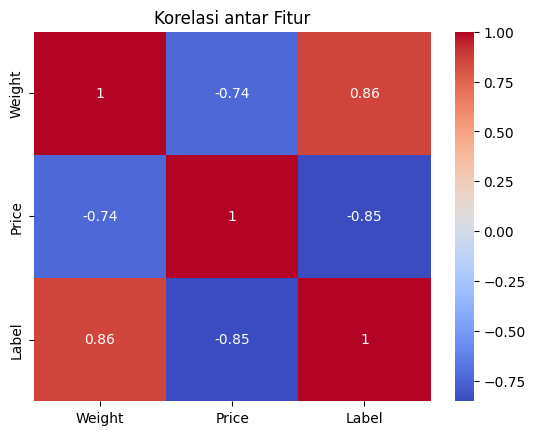

In [75]:
# Visualisasi korelasi antar fitur 
correlation = product.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur')
plt.show()

- 2 fitur independen, saling memiliki korelasi negatif dengan nilai tinggi. Sehingga, tidak ada kemungkinan adanya kemiripan data.
- Korelasi antara fitur 'Weight' dengan target, memiliki korelasi cukup tinggi. Sehingga, memiliki hubungan linear.

#### 1.4.2 Univariate Analysis

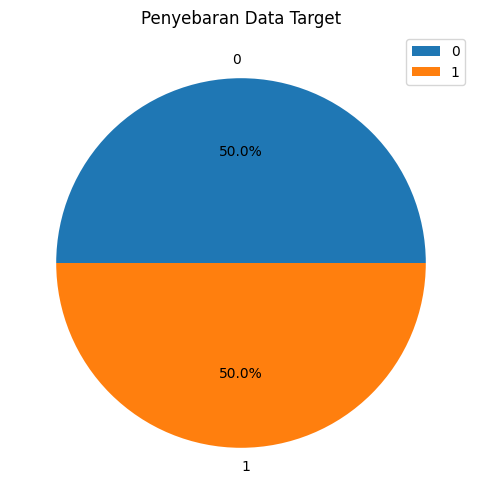

In [76]:
# Visualisasi penyebaran nilai target
counts = product['Label'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Penyebaran Data Target')
plt.legend(['0','1'])
plt.show()

- Penyebaran nilai pada target balance, sehingga tidak diperlukan resampling data.

#### 1.4.3 Bivariate Analysis

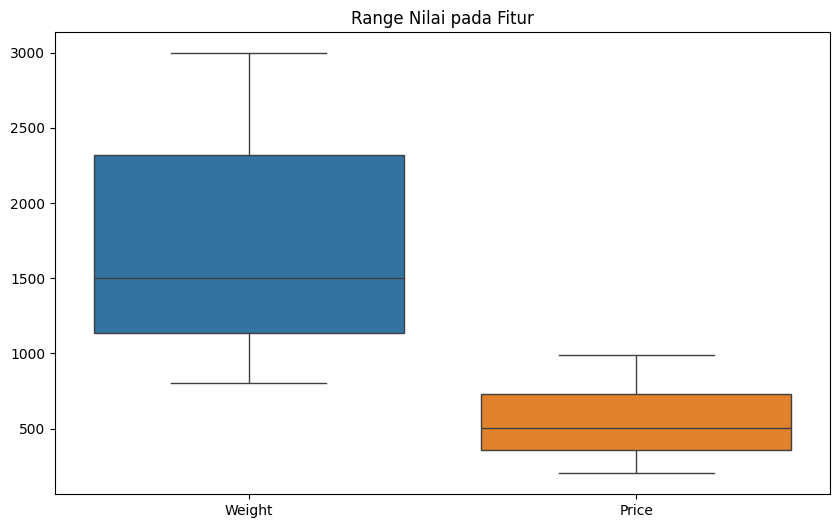

In [77]:
# Visualisasi scatter plot untuk mendeteksi nilai yang diluar range
X = product.drop('Label', axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(data=X)
plt.title("Range Nilai pada Fitur")
plt.show()

- Tidak ada nilai diluar dari range, sehigga nilai pada masing -  masing fitur merata.

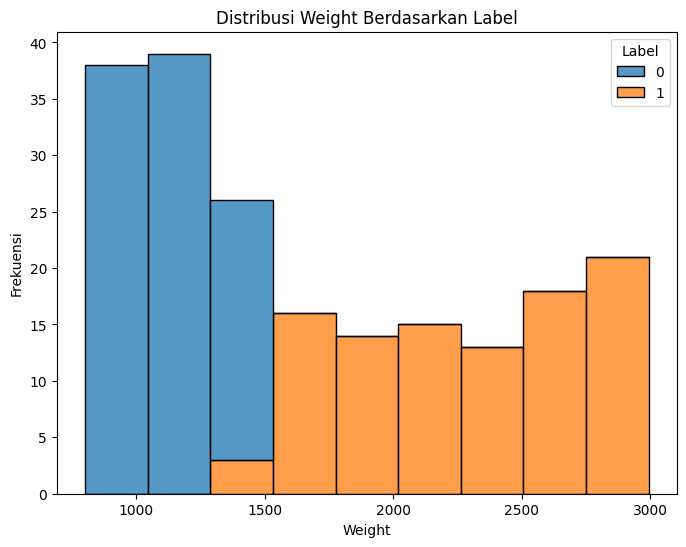

In [78]:
# Visulisasi 'Weight' vs 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=product, x='Weight', hue='Label', multiple="stack")

plt.title('Distribusi Weight Berdasarkan Label')
plt.xlabel('Weight')
plt.ylabel('Frekuensi')
plt.show()

- Produk label '0' cenderung memiliki berat yang lebih ringan daripada produk label '1', dengan range berat 0 - 1500. Sedangkan,
- Produk label '1' memiliki nilai berat yang lebih tinggi dari produk label '0' dan cukup menyebar, dengan range berat 1000 - 3000.

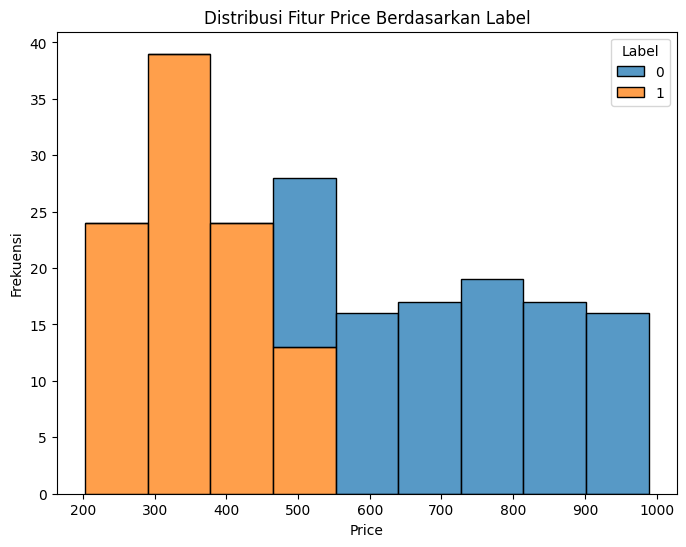

In [79]:
# Visualisasi 'Price' vs 'Label'
plt.figure(figsize=(8, 6))
sns.histplot(data=product, x='Price', hue='Label', multiple='stack')
plt.xlabel('Price')
plt.ylabel('Frekuensi')
plt.title('Distribusi Fitur Price Berdasarkan Label')
plt.show()

- Produk label '0' cenderung memiliki harga yang lebih mahal daripada produk dengan label '1' demgam ramge harga 500 - 1000. Sedangkan,
- Produk label '1' memiliki harga yang labih murah dengan range 200 - 500.

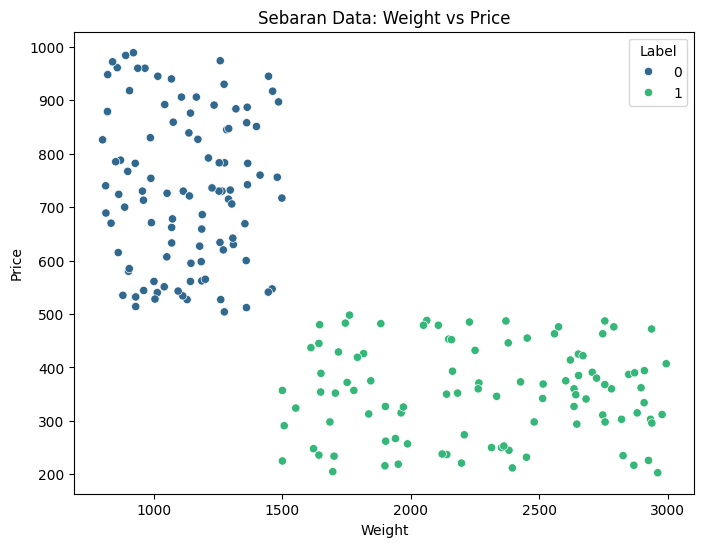

In [80]:
# Melihat sebaran Weight vs Price berdasarkan Label
plt.figure(figsize=(8, 6))
sns.scatterplot(data=product, x='Weight', y='Price', hue='Label', palette='viridis')
plt.title('Sebaran Data: Weight vs Price')
plt.show()

- Scatter diatas, menunjukkan pemisahan yang jelas antara 2 fitur. Dimana:
1. Produk label '0' -> Memiliki berat lebih ringan dengan harga lebih tinggi. Sedangkan,
2. Produk label '1' -> Memiliki nilai berat lebih tinggi dengan harga lebih murah.

## 2. Model 

### 2.1 Fitur Independent dan Dependent 

In [81]:
X = product.drop('Label', axis=1)
y = product['Label']

### 2.1 Standarisasi

In [82]:
# X = (X - X.mean()) / X - X.std()
# X = (X - X.mean()) / (X.std() + 1e-9)


### 2.2 Split Data

Split data menggunakan stratified split. Dimana:
- 80% data train, dan
- 20% data test

In [83]:
# fungsi stratified split
def split_data(X, y, size=0.7):
    np.random.seed(42)

    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    train_0 = int(len(idx_0) * size)
    train_1 = int(len(idx_1) * size)

    train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
    test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values
    X_test = X.iloc[test_idx].values
    y_test = y.iloc[test_idx].values

    return X_train, y_train, X_test, y_test

In [84]:
# Panggil fungsi split
X_train, y_train, X_test, y_test = split_data(X, y, size=0.8)

In [85]:
# Feature scalling
def scaling(X):
    n_features = len(X[0])
    mean = []
    std = []

    for j in range(n_features):
        column = [row[j] for row in X]
        m = sum(column) / len(column) # Menghitung mean
        s = (sum((x - m)**2 for x in column) / len(column))**0.5 #menghitung std
        mean.append(m)
        std.append(s)
    return mean, std

def apply(X, mean, std):
    X_scaled = []
    for row in X:
        new_row = []
        for j in range(len(row)):
            scaled = (row[j] - mean[j]) / (std[j] + 1e-9) # Standarisasi
            new_row.append(scaled)
        X_scaled.append(new_row)
    return X_scaled

mean, std = scaling(X_train)

X_train_scaled = apply(X_train, mean, std)
X_test_scaled = apply(X_test, mean, std)

### 2.3 Model SVM

In [ ]:
# Model SVM
def train_svm(X, y, learning_rate=0.0001, lambda_param=0.001, n_iters=500):
    n_sampled, n_features = len(X), len(X[0])
    w = [0.0] * n_features
    b = 0.0
    y_svm = [1 if val == 1 else -1 for val in y] 

    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            y_i = y_svm[idx]
            approx = sum(x_i[j] * w[j] for j in range(n_features)) + b 
            condition = y_i * approx >= 1

            if condition:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j])
            else:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j] - x_i[j] * y_i)
                b -= learning_rate * y_i
    return w, b

weights, bias = train_svm(X_train_scaled, y_train)

### 2.4 Predict

In [87]:
# Fungsi Prediksi 
def predict(X, w, b):
    predictions = []
    for x_i in X:
        approx = sum(x_i[j] * w[j] for j in range(len(w))) + b
        predictions.append(1 if approx >= 0 else -1)
    return predictions

y_pred_test = predict(X_test_scaled, weights, bias)
y_pred_train = predict(X_train_scaled, weights, bias)

## 3. Evaluasi

In [ ]:
# Hitung akurasi train dan test 
def calculate_accuracy(y_true, y_pred):
    y_true_converted = [1 if x == 1 else -1 for x in y_true]
    correct_predictions = 0
    for i in range(len(y_true_converted)):
        if y_true_converted[i] == y_pred[i]:
            correct_predictions += 1

    return (correct_predictions / len(y_true_converted)) * 100

accuracy_test = calculate_accuracy(y_test, y_pred_test)
accuracy_train = calculate_accuracy(y_train, y_pred_train)

In [89]:
# Hitung evaluasi 
def calculate_metrics(y_true, y_pred):
    y_true_converted = [1 if x == 1 else -1 for x in y_true]
    tp, fp, fn, tn = 0, 0, 0, 0

    for i in range(len(y_true_converted)):
        if y_true_converted[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true_converted[i] == -1 and y_pred[i] == 1:
            fp += 1
        elif y_true_converted[i] == 1 and y_pred[i] == -1:
            fn += 1
        elif y_true_converted[i] == -1 and y_pred[i] == -1:
            tn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score, (tp, fp, fn, tn)

precision, recall, f1_score, cm_values = calculate_metrics(y_test, y_pred_test)
tp, fp, fn, tn = cm_values

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Accuracy Test: {accuracy_test:.2f}")
print(f"Accuracy Train: {accuracy_train:.2f}")

Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Accuracy Test: 100.00
Accuracy Train: 100.00


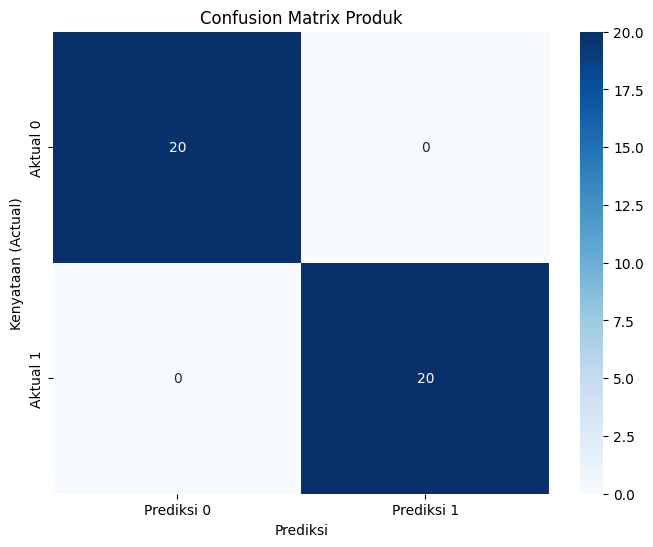

In [90]:
# Visualisasi Convusion Matrix
def plot_cm(tp, fp, fn, tn):
    cm = [[tn, fp], 
          [fn, tp]] # Format standar CM
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Prediksi 0', 'Prediksi 1'],
                yticklabels=['Aktual 0', 'Aktual 1'])
    plt.xlabel('Prediksi')
    plt.ylabel('Kenyataan (Actual)')
    plt.title('Confusion Matrix Produk')
    plt.show()

plot_cm(tp, fp, fn, tn)


Model memprediksi cukup baik dengan kesalahan yang sangat sedikit

## 4. Visualisasi 

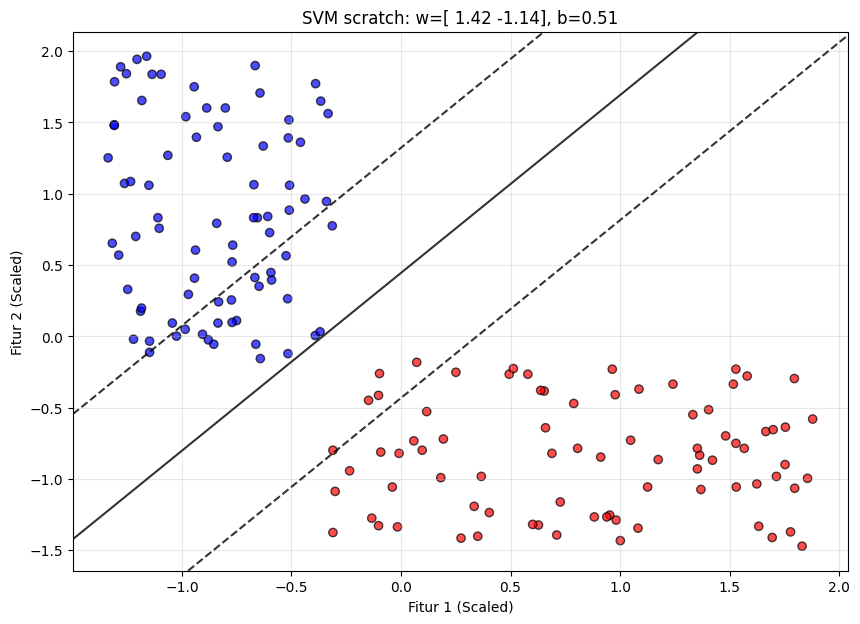

In [ ]:
# Fungsi Visualisasi 

def visualize_svm_final(X, y, weights, bias):
    X = np.array(X)
    
    y = np.array(y)
    w = np.array(weights)

    plt.figure(figsize=(10, 7))

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)

    Z = (w[0] * XX + w[1] * YY + bias)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'])

    plt.title(f"SVM scratch: w={w.round(2)}, b={round(bias, 2)}")
    plt.xlabel("Fitur 1 (Scaled)")
    plt.ylabel("Fitur 2 (Scaled)")
    plt.grid(True, alpha=0.3)
    # plt.legend(loc='upper right')
    plt.show()

visualize_svm_final(X_train_scaled, y_train, weights, bias)

Prediksi sudah bagus walau ada 3 data yang melewati garis hyperplane, kami biarkan karena dia hanya mempengaruhi 1-2% akurasi model.

## 5. GUI

In [92]:
root = tk.Tk()
root.configure(bg="#1E1D1F")

def button_prediksi():
    try:
        input_produk = float(entry1.get())
        input_weight = float(entry2.get())
        input_scaled = [(input_produk - mean[0]) / (std[0] + 1e-9),
                        (input_weight - mean[1]) / (std[1] + 1e-9)]
        prediction = predict([input_scaled], weights, bias)[0]
        kategori = "Kategori 1" if prediction == 1 else "Kategori 0"
        messagebox.showinfo("Hasil Prediksi", f"Produk termasuk dalam: {kategori}")
    except ValueError:
        messagebox.showerror("Input Error", "Masukkan nilai numerik yang valid.")
    return

# frame
frame = tk.Frame(root)
frame.configure(bg="#1E1D1F")
frame.place(relx=0.5, rely=0.30, anchor='center')

# label1
label1 = tk.Label(frame,
                  text="Klasifikasi Produk",
                  font=('Arial', 25, 'bold'),
                  bg="#1E1D1F",
                  fg="#FFFFFF")
label1.pack()

# label2
label2 = tk.Label(frame,
                  text="Weights",
                  font=("Arial", 15, "bold"),
                  bg=('#1E1D1F'),
                  fg=('#FFFFFF'))
label2.pack(pady=30)

# entry1
entry1 = tk.Entry(frame,
                  font=("Arial", 20),
                  bg="#4C4B4C",
                  fg='#FFFFFF')
entry1.pack()

# label3
label3 = tk.Label(frame,
                  text="Price",
                  font=("Arial", 15, "bold"),
                  bg=('#1E1D1F'),
                  fg=('#FFFFFF'))
label3.pack(pady=15)

# entry2
entry2 = tk.Entry(frame,
                  font=("Arial", 20),
                  bg="#4C4B4C",
                  fg='#FFFFFF')
entry2.pack(pady=15)

# button1
button1 = tk.Button(frame,
                    text="Press",
                    font=("Arial", 15),
                    bg="#4C4B4C",
                    fg="#FFFFFF",
                    command=button_prediksi)
button1.pack(pady=30)

root.mainloop()

In [93]:
product.sample(5)

,Weight,Price,Label
160,2454,455,1
14,899,767,0
109,2183,352,1
19,1143,561,0
122,2604,375,1
